# Notebook 05 - Extraction de la trajectoire

Nous avons pour objectif d'extraire la trajectoire globale de la voiture ? partir des points suivis par Lucas-Kanade. La trajectoire estim?e vient des points suivis, pas du groundtruth.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "car" / "car-11"
IMG_DIR = DATA_DIR / "img"
RESULTS_DIR = PROJECT_ROOT / "results"
PLOTS_DIR = RESULTS_DIR / "plots"
FRAMES_DIR = RESULTS_DIR / "frames_output"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
FRAMES_DIR.mkdir(parents=True, exist_ok=True)

print("Racine du projet:", PROJECT_ROOT)

import cv2
import numpy as np
import matplotlib.pyplot as plt

from src.preprocessing import load_image, load_image_sequence, preprocess_image
from src.segmentation import otsu_segmentation, adaptive_segmentation, clean_mask, keep_largest_component, create_roi_mask, paste_roi_mask_to_full_image
from src.detection import detect_good_features, filter_points_inside_mask
from src.optical_flow import compute_lucas_kanade, filter_valid_flow
from src.trajectory import (
    robust_center,
    filter_points_by_displacement,
    filter_points_by_distance_to_center,
    filter_center_jump,
    save_trajectory_csv,
    compute_groundtruth_centers,
    compare_trajectory_with_groundtruth,
)
from src.visualization import plot_trajectory, plot_comparison_with_groundtruth

Racine du projet: c:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\motion-estimation-project


## Param?tres de suivi

Nous utilisons les param?tres impos?s. Le filtrage limite les d?placements aberrants, les points trop loin du centre et les sauts de centre trop grands.

In [2]:
MANUAL_ROI = (535, 300, 225, 105)
MAX_POINT_DISPLACEMENT = 30
MAX_DISTANCE_TO_CENTER = 70
MAX_CENTER_JUMP = 80
MIN_POINTS = 8
REDETECTION_INTERVAL = 5

lk_params = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03),
)

In [3]:
def detect_points_for_tracking(gray, center=None, use_initial_roi=False):
    if center is None or use_initial_roi:
        roi = MANUAL_ROI
    else:
        roi_w, roi_h = MANUAL_ROI[2], MANUAL_ROI[3]
        cx, cy = center
        roi = (int(cx - roi_w / 2), int(cy - roi_h / 2), roi_w, roi_h)

    x, y, w, h = roi
    height, width = gray.shape[:2]
    x = max(0, min(x, width - 1))
    y = max(0, min(y, height - 1))
    w = max(1, min(w, width - x))
    h = max(1, min(h, height - y))
    roi = (x, y, w, h)

    gray_roi = gray[y:y+h, x:x+w]
    mask_roi = keep_largest_component(clean_mask(otsu_segmentation(gray_roi), kernel_size=(5, 5), closing_iter=2, opening_iter=1))
    mask = paste_roi_mask_to_full_image(mask_roi, gray.shape, roi)
    points = detect_good_features(gray, mask, maxCorners=80, qualityLevel=0.01, minDistance=7, blockSize=7)
    points = filter_points_inside_mask(points, mask)

    if len(points) < MIN_POINTS:
        roi_mask = create_roi_mask(gray.shape, roi)
        points = detect_good_features(gray, roi_mask, maxCorners=80, qualityLevel=0.01, minDistance=7, blockSize=7)
        points = filter_points_inside_mask(points, roi_mask)
    return points

## Suivi frame par frame

Nous calculons le centre robuste avec la m?diane des points. La m?diane est moins sensible aux points aberrants que la moyenne.

In [4]:
image_paths = load_image_sequence(IMG_DIR)
prev_frame = load_image(image_paths[0])
prev_gray = preprocess_image(prev_frame)
points = detect_points_for_tracking(prev_gray)
previous_center = robust_center(points)

trajectory = [{"frame_id": 0, "center_x": previous_center[0], "center_y": previous_center[1], "nb_points": len(points)}]
print("Frame 0:", previous_center, "points:", len(points))

for frame_id, image_path in enumerate(image_paths[1:], start=1):
    curr_frame = load_image(image_path)
    curr_gray = preprocess_image(curr_frame)

    points_new, status, error = compute_lucas_kanade(prev_gray, curr_gray, points, lk_params)
    old_valid, new_valid = filter_valid_flow(points, points_new, status)
    old_valid, new_valid = filter_points_by_displacement(old_valid, new_valid, max_displacement=MAX_POINT_DISPLACEMENT)

    current_center = robust_center(new_valid)
    if current_center is not None:
        close_points = filter_points_by_distance_to_center(new_valid, current_center, max_distance=MAX_DISTANCE_TO_CENTER)
        if len(close_points) >= MIN_POINTS:
            new_valid = close_points
            current_center = robust_center(new_valid)

    current_center = filter_center_jump(previous_center, current_center, max_jump=MAX_CENTER_JUMP)

    if current_center is None:
        current_center = previous_center

    if len(new_valid) < MIN_POINTS:
        redetected = detect_points_for_tracking(curr_gray, center=current_center)
        if len(redetected) >= MIN_POINTS:
            points = redetected
            current_center = robust_center(points)
        else:
            points = new_valid
    elif frame_id % REDETECTION_INTERVAL == 0:
        refreshed = detect_points_for_tracking(curr_gray, use_initial_roi=True)
        if len(refreshed) >= MIN_POINTS:
            points = refreshed
            current_center = robust_center(points)
        else:
            points = new_valid
    else:
        points = new_valid

    trajectory.append({
        "frame_id": frame_id,
        "center_x": current_center[0],
        "center_y": current_center[1],
        "nb_points": len(points),
    })

    previous_center = current_center
    prev_gray = curr_gray

    if frame_id % 200 == 0:
        print(f"Frame {frame_id}: centre={current_center}, points={len(points)}")

trajectory_df = save_trajectory_csv(trajectory, RESULTS_DIR / "trajectory_estimated.csv")
trajectory_df.head()

Frame 0: (627.0, 350.5) points: 60
Frame 200: centre=(637.0, 351.0), points=27
Frame 400: centre=(599.0, 338.5), points=54
Frame 600: centre=(617.0, 358.5), points=66
Frame 800: centre=(645.0, 356.0), points=77
Frame 1000: centre=(618.5, 370.5), points=32
Frame 1200: centre=(642.0, 358.0), points=47
Frame 1400: centre=(582.5, 350.5), points=26
Frame 1600: centre=(622.0, 367.5), points=14


,frame_id,center_x,center_y,nb_points
0,0,627.000000,350.500000,60
1,1,621.393921,339.999298,38
2,2,617.734863,337.203674,37
3,3,616.477600,337.255096,37
4,4,615.217590,337.044220,37


Nous observons que la trajectoire est construite progressivement ? partir du centre robuste des points suivis. Les red?tections servent seulement lorsque le nombre de points devient insuffisant.

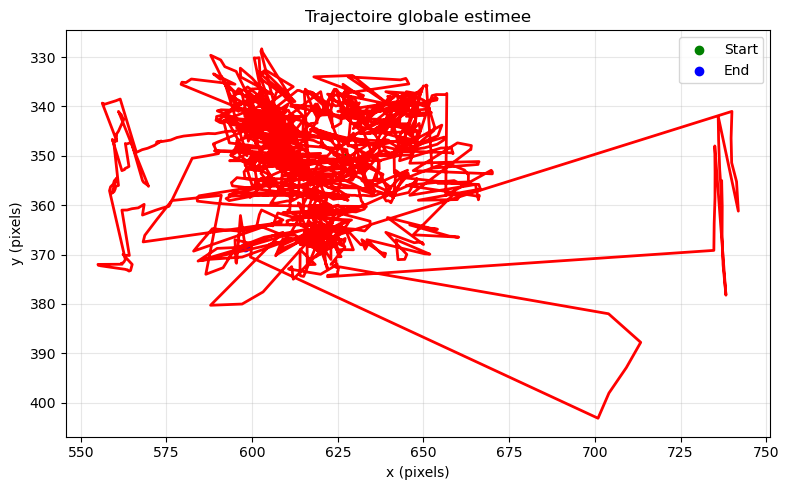

In [5]:
fig = plot_trajectory(trajectory_df, save_path=PLOTS_DIR / "trajectory_2d.png")
plt.show()

Nous interpr?tons cette courbe comme la trajectoire globale estim?e de la voiture dans le plan image.

## Comparaison finale avec groundtruth

Cette section est s?par?e de la m?thode de suivi. Nous utilisons `groundtruth.txt` uniquement pour comparer le r?sultat estim? avec les annotations.

Erreur moyenne: 19.28 px
Erreur maximale: 118.27 px


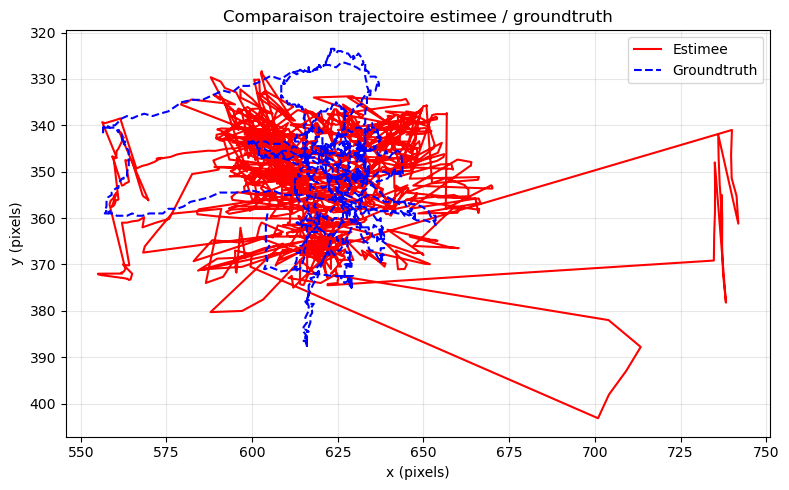

In [6]:
gt_df = compute_groundtruth_centers(DATA_DIR / "groundtruth.txt")
comparison_df = compare_trajectory_with_groundtruth(trajectory_df, gt_df)
mean_error = comparison_df["error_px"].mean()
max_error = comparison_df["error_px"].max()
print(f"Erreur moyenne: {mean_error:.2f} px")
print(f"Erreur maximale: {max_error:.2f} px")

fig = plot_comparison_with_groundtruth(trajectory_df, gt_df, save_path=PLOTS_DIR / "comparison_groundtruth.png")
plt.show()

Nous interpr?tons l'erreur comme un indicateur d'?valuation. Le groundtruth n'a pas servi ? suivre l'objet, mais seulement ? mesurer l'?cart final.